In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rozamakima77/kepler-objects-of-interest/cumulative_2026.08.09_23.01.37.csv


# Kepler Exoplanet Classifier - Exploratory Data Analysis
NASA Kepler telescope data diye planet candidate vs false positive classify korার project.

In [3]:
## 1. Load Dataset
# Import required libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Kepler exoplanet dataset from CSV
df = pd.read_csv('/kaggle/input/datasets/rozamakima77/kepler-objects-of-interest/cumulative_2026.08.09_23.01.37.csv', comment='#')
df.head()

,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [4]:
## 2. Data Overview
# Check total rows/columns and inspect data types + missing values
print(df.shape)
df.info()

## 3. Target Variable Distribution
# Check how many CANDIDATE vs FALSE POSITIVE labels exist in the target column
df['koi_pdisposition'].value_counts()

(9564, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kepid              9564 non-null   int64  
 1   kepoi_name         9564 non-null   object 
 2   kepler_name        2747 non-null   object 
 3   koi_disposition    9564 non-null   object 
 4   koi_pdisposition   9564 non-null   object 
 5   koi_score          8054 non-null   float64
 6   koi_fpflag_nt      9564 non-null   int64  
 7   koi_fpflag_ss      9564 non-null   int64  
 8   koi_fpflag_co      9564 non-null   int64  
 9   koi_fpflag_ec      9564 non-null   int64  
 10  koi_period         9564 non-null   float64
 11  koi_period_err1    9110 non-null   float64
 12  koi_period_err2    9110 non-null   float64
 13  koi_time0bk        9564 non-null   float64
 14  koi_time0bk_err1   9110 non-null   float64
 15  koi_time0bk_err2   9110 non-null   float64
 16  koi_impact   

koi_pdisposition
FALSE POSITIVE    4847
CANDIDATE         4717
Name: count, dtype: int64

## 3. Target Variable Distribution

Checking the balance between CANDIDATE and FALSE POSITIVE labels.


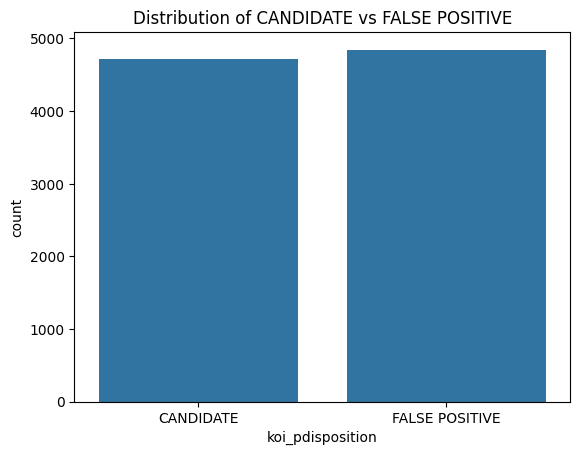

In [5]:
# Check how many CANDIDATE vs FALSE POSITIVE labels exist in the target column
df['koi_pdisposition'].value_counts()
# Visualize the class distribution as a bar chart
sns.countplot(data=df, x='koi_pdisposition')
plt.title('Distribution of CANDIDATE vs FALSE POSITIVE')
plt.savefig('/kaggle/working/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Exploration

Checking how key numeric features differ between CANDIDATE and FALSE POSITIVE.


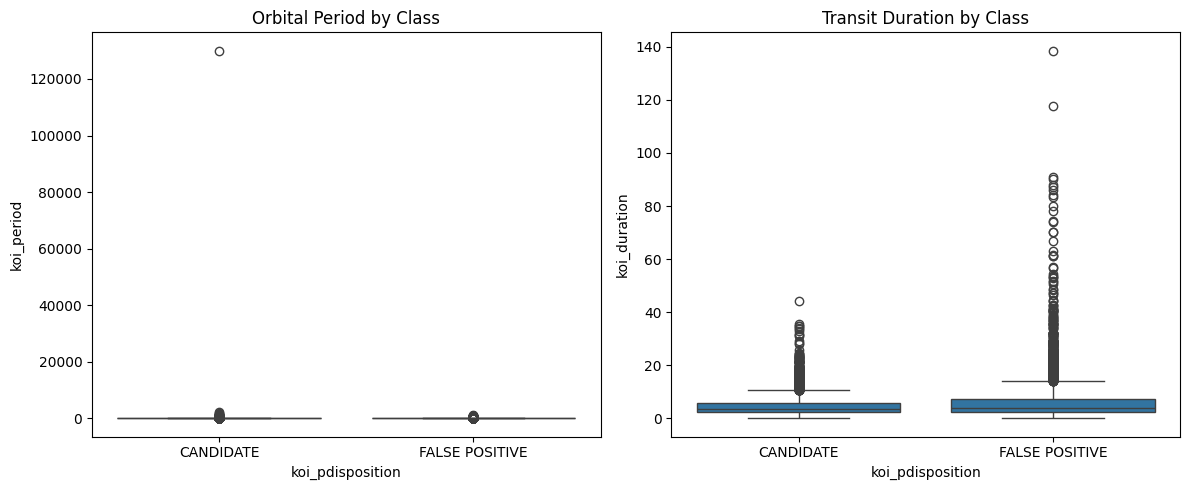

In [6]:
# Compare orbital period and transit duration across the two classes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='koi_pdisposition', y='koi_period', ax=axes[0])
axes[0].set_title('Orbital Period by Class')

sns.boxplot(data=df, x='koi_pdisposition', y='koi_duration', ax=axes[1])
axes[1].set_title('Transit Duration by Class')

plt.savefig('/kaggle/working/feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 5. Handling Missing Values

Dropping completely empty columns and columns not useful for prediction, then filling small gaps in numeric features.

In [7]:
# Drop columns that are completely empty (all values missing)
df = df.drop(columns=['koi_teq_err1', 'koi_teq_err2'])

# Drop identifier and text columns that don't help prediction
df = df.drop(columns=['kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname'])

# Check remaining missing values
df.isnull().sum().sort_values(ascending=False).head(15)



koi_score            1510
koi_steff_err2        483
koi_slogg_err1        468
koi_slogg_err2        468
koi_srad_err1         468
koi_srad_err2         468
koi_steff_err1        468
koi_time0bk_err2      454
koi_time0bk_err1      454
koi_period_err1       454
koi_period_err2       454
koi_duration_err2     454
koi_duration_err1     454
koi_impact_err1       454
koi_impact_err2       454
dtype: int64

In [8]:
# Drop completely empty columns and identifier columns (safe to re-run)
cols_to_drop = ['koi_teq_err1', 'koi_teq_err2', 'kepid', 'kepoi_name', 'kepler_name', 'koi_tce_delivname']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Check remaining missing values
df.isnull().sum().sort_values(ascending=False).head(15)

koi_score            1510
koi_steff_err2        483
koi_slogg_err1        468
koi_slogg_err2        468
koi_srad_err1         468
koi_srad_err2         468
koi_steff_err1        468
koi_time0bk_err2      454
koi_time0bk_err1      454
koi_period_err1       454
koi_period_err2       454
koi_duration_err2     454
koi_duration_err1     454
koi_impact_err1       454
koi_impact_err2       454
dtype: int64

## 6. Filling Missing Values

Filling numeric gaps with median values (robust to outliers), since dropping ~500 rows would lose valid data.

In [9]:
# Fill missing numeric values with the median of each column
# Median is used instead of mean because it's less affected by outliers
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Confirm no missing values remain in numeric columns
df.isnull().sum().sum()

np.int64(0)

## 7. Correlation Heatmap

Checking which numeric features are strongly related to each other.

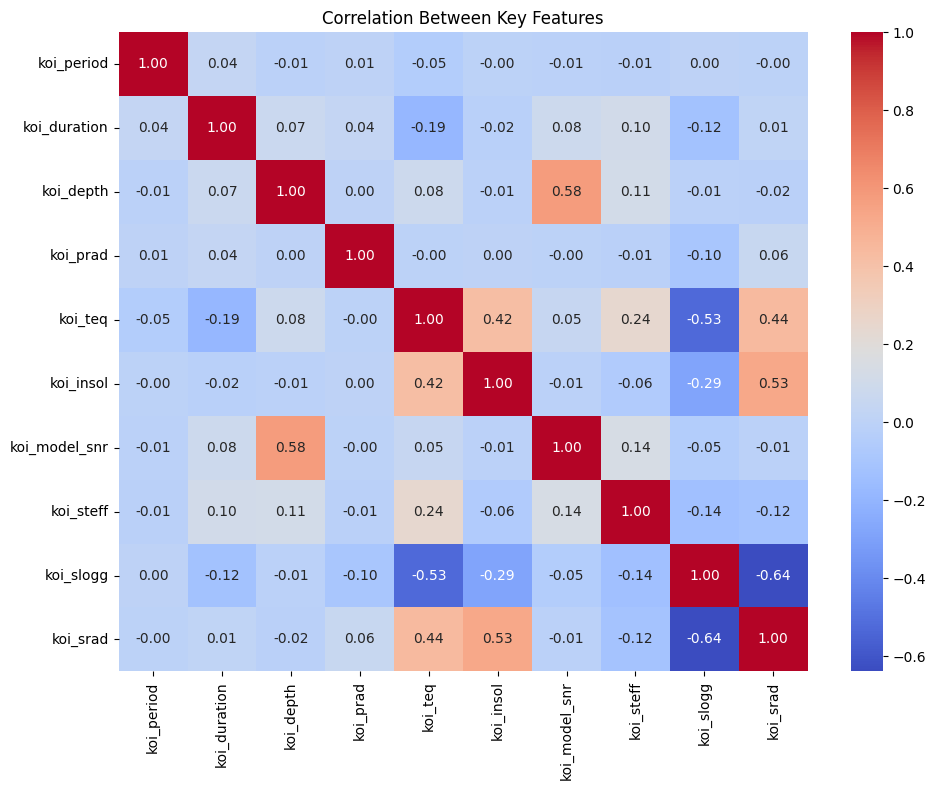

In [10]:
# Select a subset of key features to check correlation (full 49 columns would be unreadable)
key_features = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 
                 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 
                 'koi_slogg', 'koi_srad']

# Calculate correlation matrix
corr_matrix = df[key_features].corr()

# Plot as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Key Features')
plt.savefig('/kaggle/working/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [11]:
# Convert target labels to binary numbers: CANDIDATE = 1, FALSE POSITIVE = 0
df['target'] = df['koi_pdisposition'].map({'CANDIDATE': 1, 'FALSE POSITIVE': 0})

# Confirm the mapping worked correctly
df['target'].value_counts()

target
0    4847
1    4717
Name: count, dtype: int64